# TP : Classification Fashion-MNIST sans Convolution

Ce TP vous guide dans la mise en œuvre complète, de la préparation des données à l'analyse des performances, d'un classifieur perceptron multicouche appliqué au jeu de données Fashion-MNIST. 

Vous suivrez pas à pas la construction du pipeline afin d'aborder la préparation des données, l'entraînement supervisé, la validation et l'interprétation des résultats obtenus.


### Préparer l'environnement logiciel

Importez l'ensemble des bibliothèques utiles à la séance : `matplotlib.pyplot` pour la visualisation, `torch` et `torch.nn` pour la manipulation de tenseurs et la définition du modèle, `torchvision.datasets` pour l'accès à Fashion-MNIST, `torch.utils.data` pour les structures `Dataset` et `DataLoader`, ainsi que `numpy`, `tqdm` et les métriques de `sklearn` nécessaires aux évaluations. On importera finalement `os` pour manipuler les fichiers.


In [1]:
import matplotlib.pyplot as plt
from torchvision import datasets
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import numpy as np  
from tqdm import tqdm
from sklearn.metrics import classification_report
from torch.utils.data import random_split
import os

### Constituer le corpus Fashion-MNIST

Téléchargez la portion d'<u>entraînement</u> du jeu de données Fashion-MNIST à l'aide de `datasets.FashionMNIST`, en indiquant un répertoire local de stockage, en activant l'option `download=True` et en conservant l'objet retourné pour les traitements ultérieurs.


In [ ]:
# Télécharger le dataset FashionMNIST
data_dir = './data/'
full_mnist = datasets.FashionMNIST(data_dir, download=True, train=True)

### Explorer visuellement un exemple du dataset

Implémentez la fonction `show_fmnist_image(dataset, idx)` qui :
- extrait une image et son étiquette textuelle depuis `dataset`, 
- affiche la matrice en niveaux de gris avec `matplotlib`, 
- ajoute un titre représentant l'étiquette,
- renseigne la forme (shape) ainsi que les valeurs minimale et maximale contenues.


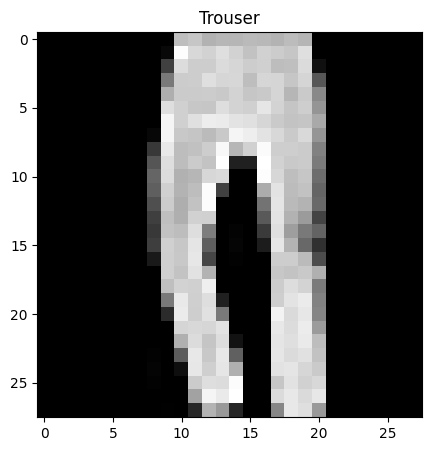

Image shape : torch.Size([28, 28])
Min value: 0
Max value: 255


In [3]:
# Fonction pour afficher une image du dataset FashionMNIST

def show_fmnist_image(dataset, idx):
    img = dataset.data[idx]
    label = dataset.targets[idx].item()
    label_txt = dataset.classes[label]
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(label_txt)
    plt.show()
    print("Image shape :", img.shape)
    print("Min value:", img.min().item())
    print("Max value:", img.max().item())

show_fmnist_image(full_mnist, 24300)

### Inventorier les catégories Fashion-MNIST

Affichez le nombre total de classes présentes dans `full_mnist.classes`, puis parcourez cette structure pour présenter l'intitulé de chaque catégorie en lui associant son indice.


In [4]:
# Affichage des classes du dataset FashionMNIST

print(f"FashionMNIST classes : {len(full_mnist.classes)}")
for i, cls in enumerate(full_mnist.classes):
    print(f"{i}: {cls}")

FashionMNIST classes : 10
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


### Séparer apprentissage et validation

Calculez une partition 80 % / 20 % de `full_mnist` pour obtenir les tailles d'entraînement et de validation, puis utilisez `random_split` afin de générer les deux sous-ensembles `train_mnist` et `val_mnist`.


In [5]:
# Division du dataset en ensembles d'entraînement et de validation

train_len = int(0.8 * len(full_mnist))
val_len = len(full_mnist) - train_len
train_mnist, val_mnist = random_split(full_mnist, [train_len, val_len])

### Vérifier la cardinalité des sous-ensembles

Affichez la taille de `train_mnist` et de `val_mnist` pour confirmer que la découpe précédente respecte les proportions visées.


In [6]:
# Affichage du nombre d'exemples dans chaque ensemble

print("Number of training examples:", len(train_mnist))
print("Number of validation examples:", len(val_mnist))

Number of training examples: 48000
Number of validation examples: 12000


### Structurer le jeu de données vectorisé

Définissez la classe `FMNIST_Dataset(images, labels)` héritant de `Dataset` : 
- aplatissez les images en vecteurs normalisés dans `__init__`, conservez les étiquettes, 
- implémentez `__len__()` pour renvoyer la cardinalité
- implémentez `__getitem__(index)` pour retourner le couple `(X[index], Y[index])`.


In [7]:
# Définition de la classe FMNIST_Dataset

class FMNIST_Dataset(Dataset):
    def __init__(self, images, labels):
        # Aplatir les images en vecteurs et normaliser entre 0 et 1
        self.X = images.view(images.shape[0], -1).float() / 255.0
        self.Y = labels
        self.len = len(images)

    def __len__(self):
        return self.len

    def __getitem__(self, index):        
        return self.X[index], self.Y[index]

### Instancier les partitions formatées

Sélectionnez, via les indices fournis par `train_mnist` et `val_mnist`, les tenseurs d'images et les étiquettes correspondants, puis créez deux objets `FMNIST_Dataset` dédiés respectivement à l'entraînement et à la validation.


In [8]:
# Création des datasets d'entraînement et de validation

train_images = full_mnist.data[train_mnist.indices]
train_labels = full_mnist.targets[train_mnist.indices]
val_images = full_mnist.data[val_mnist.indices]
val_labels = full_mnist.targets[val_mnist.indices]

train_dataset = FMNIST_Dataset(train_images, train_labels)
val_dataset = FMNIST_Dataset(val_images, val_labels)

### Préparer les itérateurs mini-batch

Fixez une taille de lot (`batch_size`) adaptée, par exemple 32 échantillons, qui constitue un compromis efficace entre la stabilité de l'apprentissage et l'efficacité computationnelle. 

Instanciez ensuite deux objets `DataLoader` nommés `train_loader` et `val_loader`:
- `train_loader`, associé à `train_dataset`, avec l'argument `shuffle=True` pour mélanger aléatoirement les données à chaque époque, ce qui favorise la généralisation en évitant que le modèle mémorise l'ordre des exemples
- `val_loader`, associé à `val_dataset`, avec `shuffle=False` pour préserver un ordre reproductible lors de l'évaluation

Ces DataLoader permettront de charger les données par lots lors de l'entraînement et de l'évaluation, optimisant ainsi l'utilisation de la mémoire et la vitesse de calcul.


In [9]:
# Création des DataLoaders pour l'entraînement et la validation

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

### Concevoir un perceptron multicouche simple

Implémentez la classe `SimpleFMNISTModel(input_size=28*28, num_classes=10)` dérivée de `nn.Module`.

Dans `__init__`, instanciez les couches à utiliser composées de :
- Une première couche linéaire (`nn.Linear`) prenant en entrée `input_size` neurones (784 pour des images 28×28 aplaties) et produisant 1000 neurones cachés
- Une fonction d'activation ReLU (`nn.ReLU`) pour introduire de la non-linéarité
- Une seconde couche linéaire réduisant les 1000 neurones cachés vers `num_classes` sorties (10 classes pour Fashion-MNIST)

La méthode `forward(x)` applique simplement cette séquence de couches au tenseur d'entrée `x`, qui représente un lot de vecteurs aplatis.

Ce modèle constitue un perceptron multicouche classique (MLP) sans convolution.


In [10]:
# Définition du modèle simple sans CNN

class SimpleFMNISTModel(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 1000)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(1000, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [11]:
model = SimpleFMNISTModel()
display(model)

SimpleFMNISTModel(
  (fc1): Linear(in_features=784, out_features=1000, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)

### Sélectionner le dispositif de calcul


L'utilisation d'un GPU (par exemple via CUDA pour les cartes NVIDIA) ou du backend Apple mps (Metal Performance Shaders, pour les Mac équipés de puces Apple Silicon) permet d'accélérer considérablement les calculs nécessaires à l'entraînement et à l'inférence des réseaux de neurones. Ces dispositifs sont conçus pour effectuer des opérations massivement parallèles, ce qui est particulièrement adapté aux traitements matriciels de l'apprentissage profond. 

Si aucun GPU ou backend accéléré n'est disponible, le calcul s'effectuera sur le CPU, généralement plus lent pour ce type de tâches.

Déterminez dynamiquement si un GPU CUDA ou mps est disponible ; sinon basculez sur le CPU. Affichez le dispositif retenu, puis assurez le transfert du modèle sur ce `device` afin d'harmoniser les calculs.


In [12]:
# Détection du device (GPU si disponible, sinon CPU)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### Initialiser l'instance du modèle

Placez `model` sur le `device`sélectionné.


In [13]:
model = model.to(device)

### Configurer la fonction de coût et l'optimiseur

Instanciez une perte `nn.CrossEntropyLoss` adaptée à la classification multiclasse et construisez un optimiseur `torch.optim.Adam` appliqué aux paramètres du modèle avec un taux d'apprentissage fixé à `1e-3`.


In [14]:
# Définition de la fonction de perte et de l'optimiseur

loss_fn = nn.CrossEntropyLoss() # Fonction de perte pour la classification multi-classes
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Optimiseur Adam avec un taux d'apprentissage de 0.001

### Fonction d'évaluation d'un modèle sur un DataLoader

Une fonction est nécessaire pour mesurer les performances du modèle en calculant l'exactitude globale et la perte moyenne, sans modifier les poids du réseau. 
Elle permettra de suivre l'évolution de l'apprentissage sur la validation à chaque époque et de détecter d'éventuels problèmes de sur-apprentissage en comparant les métriques obtenues sur les ensembles d'entraînement et de validation.

Rédigez la fonction `evaluate_dataloader(model, dataloader, loss_fn, device)` qui :
- place le modèle en mode évaluation avec `model.eval()`,
- désactive le calcul des gradients via `torch.no_grad()`,
- itère sur tous les lots du `dataloader` en transférant les données vers `device`,
- effectue les prédictions du modèle et calcule la perte avec `loss_fn`,
- accumule la perte totale pondérée par la taille de chaque lot,
- détermine les classes prédites avec `torch.max()` et compte les prédictions correctes,
- calcule et retourne l'exactitude moyenne (`total_correct / total_samples`) ainsi que la perte moyenne (`total_loss / total_samples`).


In [15]:
# Fonction d'évaluation du modèle

def evaluate_dataloader(model, dataloader, loss_fn, device):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            preds = model(x)
            loss = loss_fn(preds, y)
            total_loss += loss.item() * x.size(0)
            _, predicted = torch.max(preds, 1)
            total_correct += (predicted == y).sum().item()
            total_samples += y.size(0)
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


### Test de la fonction : évaluer le modèle sur l'ensemble de validation

Avant de lancer l'entraînement complet, évaluez les performances du modèle initialisé (non entraîné) sur l'ensemble de validation à l'aide de la fonction `evaluate_dataloader`. Affichez la perte et l'exactitude obtenues pour constater le niveau de performance de référence avant apprentissage.

In [16]:
loss, accuracy = evaluate_dataloader(model, val_loader, loss_fn, device)
print(f"Validation Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

Validation Loss: 2.3090, Accuracy: 0.1025


### Entrainer le modèle

Mettez en place une boucle sur un nombre défini `epochs`d'époques (par exemple 5) qui, pour chaque époque :

1. **Phase d'entraînement** :
    - Active le mode entraînement avec `model.train()`
    - Parcourt tous les mini-lots du `train_loader` avec `tqdm` pour afficher la progression
    - Pour chaque lot :
      - Transfère les données (`x`, `y`) vers le `device`
      - Effectue une passe avant avec `model(x)` pour obtenir les prédictions
      - Calcule la perte avec `loss_fn(preds, y)`
      - Réalise la rétropropagation avec `loss.backward()`
      - Met à jour les poids avec `optimizer.step()`
      - Réinitialise les gradients avec `optimizer.zero_grad()`
      - Calcule et affiche l'exactitude du lot en temps réel dans `tqdm`

2. **Phase d'évaluation** :
    - Désactive le mode entraînement avec `model.eval()`
    - Évalue le modèle sur l'ensemble d'entraînement complet via `evaluate_dataloader(model, train_loader, loss_fn, device)`
    - Évalue le modèle sur l'ensemble de validation via `evaluate_dataloader(model, val_loader, loss_fn, device)`
    - Consigne les métriques (perte et exactitude) dans des listes `train_losses`, `train_accuracies`, `val_losses`, `val_accuracies` pour le suivi de l'évolution
    - Affiche les résultats de l'époque (perte et exactitude sur train et validation)

Cette organisation permet de surveiller l'apprentissage, de détecter le surapprentissage et de suivre la convergence du modèle au fil des époques.

**NB** : On crée les listes `train_losses`, `train_accuracies`, `val_losses`, `val_accuracies` pour stocker respectivement l'ensemble des pertes et exactitudes pendant l'entraînement.


In [17]:
train_losses, train_accuracies, val_losses, val_accuracies = [], [], [], [] # Pour stocker les pertes et exactitudes pendant l'entraînement

In [18]:
epochs = 5 # Nombre d'époques d'entraînement
    
for epoch in range(epochs):

    model.train()
    
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}")    
    
    for i, batch in loop:
        x, y = batch
        x = x.to(device)
        y = y.to(device)
        
        preds = model(x)
        batch_loss = loss_fn(preds, y)
        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # batch accuracy
        _, predicted = torch.max(preds, 1)
        correct = (predicted == y).sum().item()
        accuracy = correct / y.size(0)

        loop.set_postfix({'batch_loss': batch_loss.item(), 'batch_acc': accuracy})

    model.eval()
    train_loss, train_accuracy = evaluate_dataloader(model, train_loader, loss_fn, device)
    train_accuracies.append(train_accuracy)
    train_losses.append(train_loss)
    print(f"train_loss={train_loss:.4f}, train_acc={train_accuracy:.4f}")

    val_loss, val_accuracy = evaluate_dataloader(model, val_loader, loss_fn, device)
    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)
    print(f"val_loss={val_loss:.4f}, val_acc={val_accuracy:.4f}")
    
    print("-" * 50)
    

Epoch 1: 100%|██████████| 1500/1500 [00:13<00:00, 107.79it/s, batch_loss=0.301, batch_acc=0.844]


train_loss=0.3723, train_acc=0.8652
val_loss=0.3869, val_acc=0.8599
--------------------------------------------------


Epoch 2: 100%|██████████| 1500/1500 [00:13<00:00, 107.52it/s, batch_loss=0.406, batch_acc=0.781] 


train_loss=0.3397, train_acc=0.8754
val_loss=0.3655, val_acc=0.8669
--------------------------------------------------


Epoch 3: 100%|██████████| 1500/1500 [00:13<00:00, 111.02it/s, batch_loss=0.562, batch_acc=0.781] 


train_loss=0.3079, train_acc=0.8894
val_loss=0.3427, val_acc=0.8795
--------------------------------------------------


Epoch 4: 100%|██████████| 1500/1500 [00:13<00:00, 112.95it/s, batch_loss=0.297, batch_acc=0.906] 


train_loss=0.2825, train_acc=0.8965
val_loss=0.3217, val_acc=0.8832
--------------------------------------------------


Epoch 5: 100%|██████████| 1500/1500 [00:13<00:00, 114.75it/s, batch_loss=0.27, batch_acc=0.875]  


train_loss=0.2652, train_acc=0.9014
val_loss=0.3184, val_acc=0.8845
--------------------------------------------------


### Visualiser l'évolution des performances
Tracez deux graphiques côte à côte illustrant l'évolution des performances du modèle au fil des époques. 

Utilisez `train_losses`, `train_accuracies`, `val_losses`, `val_accuracies` pour créer une figure contenant deux sous-graphiques (`plt.subplots(1, 2)`).

Le premier sous-graphique représente l'évolution de la perte : affichez les courbes de perte d'entraînement (`train_losses`) et de validation (`val_losses`) avec des légendes distinctes.

Le second sous-graphique illustre l'exactitude : tracez les courbes d'exactitude d'entraînement (`train_accuracies`) et de validation (`val_accuracies`) avec leurs légendes respectives.

Utilisez `plt.tight_layout()` pour optimiser l'espacement entre les sous-graphiques et garantir une lecture claire et professionnelle des résultats.

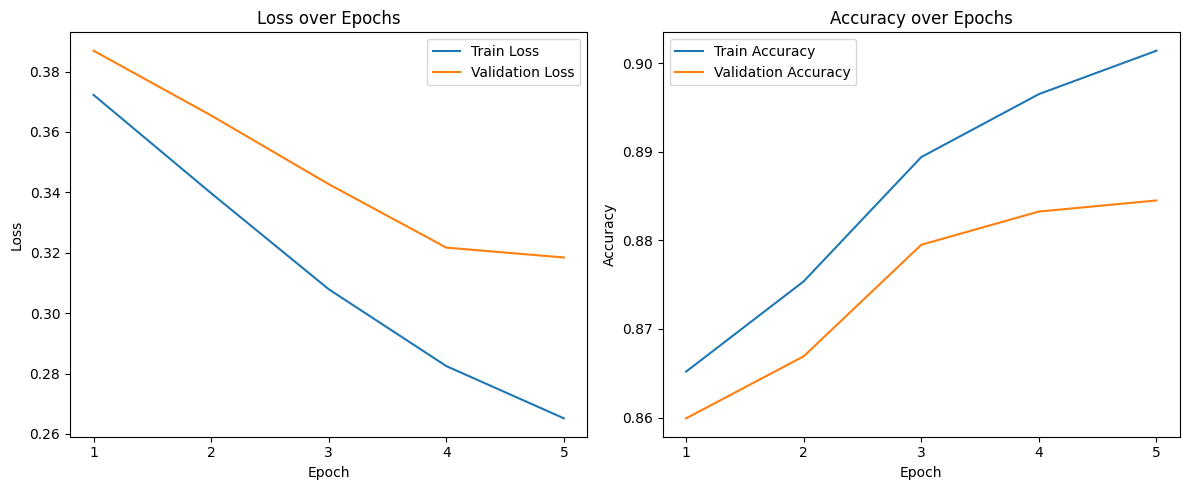

In [19]:
# Visualisation des courbes de perte et d'exactitude

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.xticks(range(1, len(train_losses)+1, 1))
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.xticks(range(1, len(train_losses)+1, 1))
plt.legend()

plt.tight_layout()
plt.show()

### Préparer la sauvegarde des paramètres appris

Rédigez les instructions nécessaires pour sérialiser l'état du modèle entraîné, par exemple en appelant `torch.save(model.state_dict(), "fmnist_model.pth")`, et prévoyez un message informant l'étudiant du chemin utilisé, même si ces lignes peuvent rester commentées pour éviter la création du fichier lors des tests.


In [ ]:
# Sauvegarde des poids du modèle entraîné

model_weights_dir = '../model_weights/'
model_name = '01_fmnist_model_no_cnn.pth'
weights_path = os.path.join(model_weights_dir, model_name)

# torch.save(model.state_dict(), weights_path) # commenté pour ne pas écraser à chaque exécution

print(f"Model weights saved to {weights_path}")

Model weights saved to ../model_weights/01_fmnist_model_no_cnn.pth


### Recharger un état entraîné

Chargez les poids précédemment sauvegardés avec `model.load_state_dict(torch.load("fmnist_model.pth", map_location=device))`, assurez-vous que le `device` est respecté et affichez une confirmation explicite.


In [21]:
# Chargement des poids du modèle sauvegardé

model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
print(f"Model weights loaded from {model_name}")

Model weights loaded from 01_fmnist_model_no_cnn.pth


### Générer un rapport de classification

Implémentez la fonction `report_on_dataloader(model, dataloader, device, classes)` qui :
- place le modèle en mode évaluation avec `model.eval()`,
- désactive le calcul des gradients via `torch.no_grad()`,
- itère sur tous les lots du `dataloader` en transférant les données vers `device`,
- effectue les prédictions du modèle avec `model(images)`,
- extrait les classes prédites avec `torch.max(outputs, 1)`,
- collecte toutes les prédictions et étiquettes réelles en les transférant sur CPU avec `.cpu().numpy()`,
- appelle `classification_report(all_labels, all_preds, target_names=classes)` pour générer un rapport détaillé incluant la précision, le rappel, le f1-score et le support pour chaque classe.


In [22]:
# Rapport de classification sur l'ensemble de validation

def report_on_dataloader(model, dataloader, device, classes):

    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=classes))

In [23]:
# Génération du rapport de classification sur l'ensemble d'entraînement
report_on_dataloader(model, train_loader, device, full_mnist.classes)

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.88      0.86      4818
     Trouser       0.99      0.99      0.99      4826
    Pullover       0.81      0.84      0.82      4801
       Dress       0.88      0.95      0.91      4809
        Coat       0.77      0.88      0.82      4782
      Sandal       1.00      0.96      0.98      4781
       Shirt       0.86      0.58      0.69      4809
     Sneaker       0.93      0.98      0.95      4799
         Bag       0.98      0.99      0.99      4767
  Ankle boot       0.98      0.96      0.97      4808

    accuracy                           0.90     48000
   macro avg       0.90      0.90      0.90     48000
weighted avg       0.90      0.90      0.90     48000



### Diagnostiquer le modèle sur la validation

Réutilisez `report_on_loader` avec `val_loader` pour analyser la qualité de généralisation du modèle et interpréter la matrice de métriques associée.


In [24]:
# Génération du rapport de classification sur l'ensemble de validation

report_on_dataloader(model, val_loader, device, full_mnist.classes)

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.85      0.85      1182
     Trouser       0.99      0.97      0.98      1174
    Pullover       0.78      0.84      0.81      1199
       Dress       0.85      0.94      0.89      1191
        Coat       0.76      0.86      0.81      1218
      Sandal       0.98      0.95      0.96      1219
       Shirt       0.82      0.54      0.65      1191
     Sneaker       0.91      0.97      0.94      1201
         Bag       0.95      0.98      0.97      1233
  Ankle boot       0.97      0.95      0.96      1192

    accuracy                           0.88     12000
   macro avg       0.89      0.88      0.88     12000
weighted avg       0.89      0.88      0.88     12000



### Tester le modèle sur le jeu de test officiel

Téléchargez la portion `train=False` de Fashion-MNIST en utilisant `datasets.FashionMNIST` avec le répertoire `data_dir` déjà défini. 

Enveloppez les données téléchargées dans une instance de `FMNIST_Dataset` en passant les tenseurs d'images et d'étiquettes correspondants. 

Construisez ensuite un `DataLoader` avec une taille de lot appropriée (par exemple 32) et sans mélange (`shuffle=False`) pour préserver l'ordre des données de test. 

Enfin, appelez la fonction `report_on_dataloader` avec le modèle entraîné, le DataLoader de test, le `device` et les noms des classes pour obtenir un rapport de classification détaillé incluant la précision, le rappel, le f1-score et le support pour chaque catégorie sur ces données inédites qui n'ont jamais été vues pendant l'entraînement ni la validation.


In [25]:
# Génération du rapport de classification sur l'ensemble de test

test_data = datasets.FashionMNIST(data_dir, download=True, train=False)
test_mnist = FMNIST_Dataset(test_data.data, test_data.targets)
test_loader = DataLoader(test_mnist, batch_size=32, shuffle=False)
report_on_dataloader(model, test_loader, device, test_data.classes)

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.84      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.75      0.80      0.78      1000
       Dress       0.84      0.93      0.88      1000
        Coat       0.73      0.84      0.78      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.80      0.55      0.66      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



### Visualiser un exemple de la classe "trousers"

Identifiez dans le jeu de test les indices correspondant à la classe `trousers` (étiquette numérique 1) en utilisant une opération de masquage sur `test_data.targets`. 

Extrayez le premier indice correspondant, récupérez l'image associée depuis `test_data.data`, puis affichez-la en niveaux de gris avec `matplotlib` en utilisant le nom de classe approprié comme titre. 

Indiquez également l'indice sélectionné.


Index of a trousers image in the test set: 2


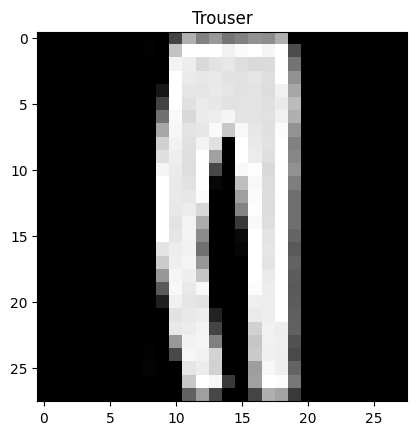

In [26]:
# Affichage d'une image de pantalon (trousers) du jeu de test

ids_where_trousers = (test_data.targets == 1).nonzero(as_tuple=True)[0]
idx = ids_where_trousers[0].item()
print("Index of a trousers image in the test set:", idx)
img = test_data.data[idx]
plt.imshow(img, cmap='gray')
plt.title(test_data.classes[1])
plt.show()

### Étude de la robustesse aux translations horizontales

Générez une grille de visualisations (`plt.subplots(2, 5)`) présentant 10 versions de l'image précédente, chacune translatée horizontalement de 0 à 9 pixels vers la droite à l'aide de `torch.roll(img, shifts=px, dims=1)`. 

Pour chaque version translatée :
- Normalisez l'image en la convertissant en tenseur flottant (`float()`), en l'aplatissant en vecteur (`view(1, -1)`) et en divisant par 255.0
- Transférez le tenseur vers le `device` approprié
- Interrogez le modèle avec `model(img_input)` en mode évaluation (sans calcul de gradients via `torch.no_grad()`)
- Extrayez la classe prédite avec `torch.argmax(output, dim=1).item()`
- Affichez l'image translatée en niveaux de gris
- Ajoutez un titre indiquant le décalage appliqué et la classe prédite correspondante (par exemple "Shift 3 → Trouser")
- Désactivez les axes pour une présentation épurée

Utilisez `plt.tight_layout()` pour optimiser l'espacement entre les sous-graphiques et observer comment les translations horizontales affectent la robustesse et la stabilité des prédictions du modèle.


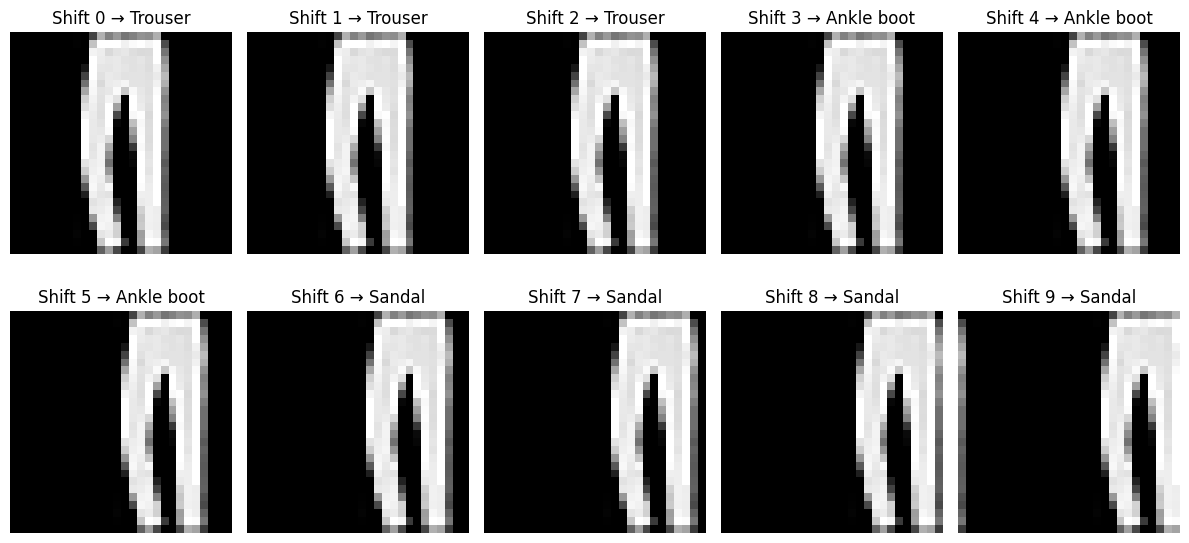

In [27]:
# Test de robustesse aux translations horizontales

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for px, ax in zip(range(10), axes.flatten()):
    shifted_img = torch.roll(img, shifts=px, dims=1)
    img_input = shifted_img.float().view(1, -1) / 255.0
    img_input = img_input.to(device)
    with torch.no_grad():
        output = model(img_input)
        pred_label = torch.argmax(output, dim=1).item()
    ax.imshow(shifted_img.cpu(), cmap='gray')
    ax.set_title(f"Shift {px} → {test_data.classes[pred_label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### Que remarquez-vous sur les performances du modèle face à ces translations horizontales ?

Le modèle montre une **sensibilité importante aux translations horizontales**. On observe que :

1. **Perte de robustesse** : Même de petits décalages (quelques pixels) peuvent conduire à des prédictions incorrectes ou instables.

2. **Absence d'invariance spatiale** : Ce perceptron multicouche traite chaque pixel comme une caractéristique indépendante à une position fixe. Un décalage de l'image modifie complètement le vecteur d'entrée du point de vue du modèle.

3. **Dépendance à la position** : Le modèle a appris à reconnaître les motifs à des positions spécifiques dans l'image. Lorsque ces motifs sont translatés, le réseau ne les reconnaît plus car il n'a pas de mécanisme pour détecter les mêmes caractéristiques à différentes positions.

Le MLP simple n'est **pas robuste aux transformations géométriques** et nécessite que les objets soient toujours centrés et alignés de la même manière que dans les données d'entraînement.

### Étudier les paramètres du modèle

Utilisez la fonction `summary` du module `torchsummary` pour afficher un résumé détaillé de l'architecture du modèle. Cette fonction présente :
- La structure des couches du réseau avec leurs dimensions de sortie
- Le nombre de paramètres par couche (entraînables et non entraînables)
- Le nombre total de paramètres du modèle
- La taille mémoire estimée pour les paramètres et les activations

Passez au `summary` le modèle et la forme d'entrée `(1, 28*28)` correspondant à une image Fashion-MNIST aplatie en vecteur de 784 éléments.

In [28]:
from torchsummary import summary
summary(model, (1, 28*28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 1, 1000]         785,000
              ReLU-2              [-1, 1, 1000]               0
            Linear-3                [-1, 1, 10]          10,010
Total params: 795,010
Trainable params: 795,010
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 3.03
Estimated Total Size (MB): 3.05
----------------------------------------------------------------
